In [1]:
import pandas as pd
import itertools
import numpy as np
import os

## 1. Data Understanding

In [5]:
raw_path = os.path.join('..', 'data', 'raw')

path_rnal = os.path.join(raw_path, 'RNAL_Estabelecimentos_de_Alojamento_Local.xlsx')

df = pd.read_csv(path_rnal)

In [6]:
df.head()

,X,Y,OBJECTID,NrRNAL,Denominacao,DataRegisto,DataAberturaPublico,Modalidade,NrUtentes,Email,...,LatLong,FiabilidadeGeo,DTMNFR,Freguesia,Concelho,Distrito,NUTSIII,NUTSII,ERT,SeloCleanSafe
0,-871301.8846,4.448274e+06,1,1,Figo,2014/12/03 09:47:03+00,2014/12/03 00:00:00+00,Apartamento,4,info@cochichosfarm.com,...,"37,0657410006129 ; -7,82703800016578",NaoFiavel,081005,Quelfes,Olhão,Faro,Algarve,Algarve,Região de Turismo do Algarve,Não
1,-873243.5191,4.447906e+06,2,2,Casa Esperança,2013/07/30 00:00:00+00,2013/07/30 00:00:00+00,Moradia,4,ana-kaisa_herlevi@kirkkonummi.fi,...,"37,0631040005519 ; -7,84447999958415",NaoFiavel,081005,Quelfes,Olhão,Faro,Algarve,Algarve,Região de Turismo do Algarve,Não
2,-851399.3893,4.456996e+06,3,3,Maria da Conceição Machado Rodrigues,2014/11/27 08:39:27+00,2014/12/05 00:00:00+00,Apartamento,4,mariacmachado3@gmail.com,...,"37,1282358204969 ; -7,64825084271288",NaoFiavel,081412,União das freguesias de Tavira (Santa Maria e ...,Tavira,Faro,Algarve,Algarve,Região de Turismo do Algarve,Não
3,-828737.7288,4.896032e+06,4,4,Bio-Turismo Casa da Eira,2014/08/06 00:00:00+00,2014/08/06 00:00:00+00,Apartamento,23,geral@casadaeira.org,...,"40,2067505368476 ; -7,44467768336503",NaoFiavel,050421,Pêro Viseu,Fundão,Castelo Branco,Beiras e Serra da Estrela,Centro,Turismo do Centro de Portugal,Não
4,-995600.0418,4.440552e+06,5,5,Casa Jesus,2009/08/18 00:00:00+00,2009/08/18 00:00:00+00,Apartamento,4,mariaprjesus@gmail.com,...,"37,0103645489463 ; -8,94362734418431",NaoFiavel,081504,Sagres,Vila do Bispo,Faro,Algarve,Algarve,Região de Turismo do Algarve,Não


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118692 entries, 0 to 118691
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   X                    118692 non-null  float64
 1   Y                    118692 non-null  float64
 2   OBJECTID             118692 non-null  int64  
 3   NrRNAL               118692 non-null  int64  
 4   Denominacao          118683 non-null  object 
 5   DataRegisto          118692 non-null  object 
 6   DataAberturaPublico  118692 non-null  object 
 7   Modalidade           118692 non-null  object 
 8   NrUtentes            118692 non-null  int64  
 9   Email                118692 non-null  object 
 10  Endereco             118692 non-null  object 
 11  CodigoPostal         118649 non-null  object 
 12  LOCALIDADE           118692 non-null  object 
 13  LatLong              118692 non-null  object 
 14  FiabilidadeGeo       118692 non-null  object 
 15  DTMNFR           

In [24]:
# missing values
missing_count = df.isnull().sum()
missing_percentage = df.isnull().mean() * 100
missing_df = pd.DataFrame({'missing_count': missing_count, 'missing_percentage': missing_percentage})
print(missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False))

              missing_count  missing_percentage
CodigoPostal             43            0.036228
Denominacao               9            0.007583


**Denominação** e **Codigo Postal** são as únicas colunas com missing values mas por enquanto não tem interesse. Para além disso a percentagem é muito baixa (<0.1%).

In [25]:
# Duplicados
duplicados = df.duplicated().sum()
print(f"\nRegistos duplicados: {duplicados}")

if duplicados > 0:
    # Ver duplicados por NrRNAL
    duplicados_rnal = df.duplicated(subset=['NrRNAL'], keep=False).sum()
    print(f"   Duplicados por NrRNAL: {duplicados_rnal}")


Registos duplicados: 0


## 2. Data Preprocessing

In [27]:
df['DataRegisto'] = pd.to_datetime(df['DataRegisto'], errors='coerce')
df['Year'] = df['DataRegisto'].dt.year
df['Month'] = df['DataRegisto'].dt.month
df_lisboa = df[df['Concelho'] == 'Lisboa'].copy()

In [28]:
# missing values
missing_count = df_lisboa.isnull().sum()
missing_percentage = df_lisboa.isnull().mean() * 100
missing_df = pd.DataFrame({'missing_count': missing_count, 'missing_percentage': missing_percentage})
print(missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False))

              missing_count  missing_percentage
CodigoPostal              9            0.048523
Denominacao               1            0.005391


In [29]:
df_lisboa['Year'] = df_lisboa['Year'].astype(int)
df_lisboa['Month'] = df_lisboa['Month'].astype(int)

In [30]:
df_lisboa['DataAberturaPublico'] = pd.to_datetime(df_lisboa['DataAberturaPublico'], errors='coerce')

In [31]:
## Data mais antiga de registo
data_mais_antiga = df_lisboa['DataRegisto'].min()
print(f"\nData mais antiga de registo: {data_mais_antiga}")


Data mais antiga de registo: 1930-06-02 00:00:00+00:00


In [32]:
## Data mais antiga de abertura ao público
data_mais_antiga_abertura = df_lisboa['DataAberturaPublico'].min()
print(f"\nData mais antiga de abertura ao público: {data_mais_antiga_abertura}")


Data mais antiga de abertura ao público: 1947-10-14 00:00:00+00:00


In [33]:
## observações com data de registo anterior a março de 2008
df_anteriores_2008 = df_lisboa[df_lisboa['DataRegisto'] < '2008-03-07']
obs_anteriores_2008 = df_anteriores_2008.shape[0]
print(f"\nObservações com data de registo anterior a março de 2008: {obs_anteriores_2008}")
df_anteriores_2008[["NrRNAL", "Denominacao", "Modalidade", "DataRegisto", "DataAberturaPublico"]]


Observações com data de registo anterior a março de 2008: 18


,NrRNAL,Denominacao,Modalidade,DataRegisto,DataAberturaPublico
481,736,Royal Gardem - Alojamento Local,Apartamento,1995-04-07 00:00:00+00:00,2014-07-30 00:00:00+00:00
1371,2189,YES! Lisbon Hostel,EstabelecimentoHospedagemHostel,2003-05-20 00:00:00+00:00,2014-12-17 00:00:00+00:00
1494,2377,Casa da lapa,Apartamento,1985-08-20 00:00:00+00:00,2014-06-02 00:00:00+00:00
2038,3213,Hello Lisbon Marques de Pombal Apartments,Apartamento,1995-01-23 00:00:00+00:00,2015-06-15 00:00:00+00:00
2142,3375,Hello Lisbon Marques de Pombal Apartments,Apartamento,1995-01-23 00:00:00+00:00,2015-06-15 00:00:00+00:00
2187,3443,Hello Lisbon Marques de Pombal Apartments,Apartamento,1995-01-23 00:00:00+00:00,2015-06-15 00:00:00+00:00
2265,3569,Hello Lisbon Marques de Pombal Apartments,Apartamento,1995-01-23 00:00:00+00:00,2015-06-15 00:00:00+00:00
2266,3570,Hello Lisbon Marques de Pombal Apartments,Apartamento,1995-01-23 00:00:00+00:00,2015-06-15 00:00:00+00:00
2269,3579,Hello Lisbon Marques de Pombal Apartments,Apartamento,1995-01-23 00:00:00+00:00,2015-06-15 00:00:00+00:00
2387,3753,Hospidagem Estrela da Serra,EstabelecimentoHospedagem,1983-03-02 00:00:00+00:00,2010-12-29 00:00:00+00:00


O Registro Nacional de Alojamento Local (RNAL) foi instituído pelo Decreto-Lei n.º 39/2008, de 7 de março de 2008, que estabeleceu o regime jurídico da instalação, exploração e funcionamento dos empreendimentos de alojamento local em Portugal (Diário da República, 2008). Portanto, qualquer registo com **DataRegisto** anterior a 7 de março de 2008 é, por definição, temporalmente impossível e constitui um erro de dados.

Diário da República, 1.ª série — N.º 48 — 7 de Março de 2008
Decreto-Lei n.º 39/2008, de 7 de março

Impacto negligenciável: Representam apenas 0,09% do dataset total (18 de 18.548 registos), com impacto estatístico desprezível.

Nota importante: A remoção baseou-se exclusivamente em **DataRegisto**. Valores de **DataAberturaPublico** anteriores a 2008 foram mantidos, uma vez que o Decreto-Lei 39/2008 teve como objetivo legalizar estabelecimentos de alojamento que já operavam informalmente antes da criação do RNAL (Diário da República, 2008). Assim, um estabelecimento com **DataAberturaPublico** de 1960 e **DataRegisto** de 2010 é considerado válido, representando um estabelecimento histórico que se formalizou posteriormente.

In [34]:
df_lisboa = df_lisboa[df_lisboa['DataRegisto'] >= '2008-03-07']

In [35]:
df_lisboa['Abertura_Antes_Registo'] = (
    df_lisboa['DataAberturaPublico'].dt.date < df_lisboa['DataRegisto'].dt.date
).astype(int)

In [36]:
df_lisboa['dias_desfasamento'] = (df_lisboa['DataRegisto'] - df_lisboa['DataAberturaPublico']).dt.days

# Criar as variáveis específicas baseadas na tua justificação teórica
# 1. Burocracia normal (0 a 30 dias de desfasamento)
df_lisboa['al_lag_admin'] = ((df_lisboa['dias_desfasamento'] > 0) & (df_lisboa['dias_desfasamento'] <= 30)).astype(int)

# 2. Proxy de Mercado Paralelo (> 365 dias de desfasamento)
df_lisboa['al_legalizacao_informal'] = (df_lisboa['dias_desfasamento'] > 365).astype(int)

In [37]:
# Agrupar para saber o que aconteceu em CADA mês (O Fluxo)
# Conta o número de ALs (OBJECTID) e soma a capacidade (NrUtentes)
# Agrupar (O Fluxo Mensal)
rnal_fluxo = df_lisboa.groupby(['Freguesia', 'Year', 'Month']).agg(
    novos_al=('OBJECTID', 'count'),
    novas_camas=('NrUtentes', 'sum'),
    novos_lag_admin=('al_lag_admin', 'sum'),                     # Novos atrasos normais neste mês
    novos_legalizados_informal=('al_legalizacao_informal', 'sum') # Novas legalizações forçadas neste mês
).reset_index()

rnal_fluxo = rnal_fluxo.rename(columns={'Freguesia': 'parish'})

In [38]:
freguesias_lisboa = [
    'Ajuda', 'Alcântara', 'Alvalade', 'Areeiro', 'Arroios', 'Avenidas Novas', 
    'Beato', 'Belém', 'Benfica', 'Campo de Ourique', 'Campolide', 'Carnide', 
    'Estrela', 'Lumiar', 'Marvila', 'Misericórdia', 'Olivais', 'Parque das Nações', 
    'Penha de França', 'Santa Clara', 'Santa Maria Maior', 'Santo António', 
    'São Domingos de Benfica', 'São Vicente'
]

# Criar todos os meses desde o início do RNAL (Março 2008) até ao fim do teu target
datas_grelha = pd.date_range(start='2008-03-01', end='2025-11-01', freq='MS')

# Produto Cartesiano: Todas as Freguesias x Todos os Meses
grelha = pd.DataFrame(list(itertools.product(freguesias_lisboa, datas_grelha)), columns=['parish', 'date'])
grelha['Year'] = grelha['date'].dt.year
grelha['Month'] = grelha['date'].dt.month

# Fazer o Left Join do fluxo na grelha. Os meses sem ALs novos recebem NaN, que convertemos a 0.
rnal_grelha = pd.merge(grelha, rnal_fluxo, on=['parish', 'Year', 'Month'], how='left')

# Preencher os buracos (meses sem novos registos) com ZEROS
colunas_preencher = ['novos_al', 'novas_camas', 'novos_lag_admin', 'novos_legalizados_informal']
rnal_grelha[colunas_preencher] = rnal_grelha[colunas_preencher].fillna(0)
# Ordenar cronologicamente por freguesia (OBRIGATÓRIO antes do cumsum)
rnal_grelha = rnal_grelha.sort_values(by=['parish', 'date']).reset_index(drop=True)

# Total Acumulado (O Stock real de AL e Capacidade em qualquer dado mês)
rnal_grelha['total_al_acumulado'] = rnal_grelha.groupby('parish')['novos_al'].cumsum()
rnal_grelha['total_camas_acumulado'] = rnal_grelha.groupby('parish')['novas_camas'].cumsum()
# Acumulado das variáveis de desfasamento (se as tiveres criado no Passo 1)
if 'novos_legalizados_informal' in rnal_grelha.columns:
    rnal_grelha['stock_lag_admin_acumulado'] = rnal_grelha.groupby('parish')['novos_lag_admin'].cumsum()
    rnal_grelha['stock_legalizados_informal_acumulado'] = rnal_grelha.groupby('parish')['novos_legalizados_informal'].cumsum()

In [39]:
# Áreas das freguesias de Lisboa em km² (dgterritorio.gov.pt - CAOP 2024)
areas_freguesias = {
    'Ajuda': 2.88,
    'Alcântara': 5.07,
    'Alvalade': 5.34,
    'Areeiro': 1.74,
    'Arroios': 2.13,
    'Avenidas Novas': 2.99,
    'Beato': 2.48,
    'Belém': 10.43,
    'Benfica': 8.02,
    'Campo de Ourique': 1.65,
    'Campolide': 2.77,
    'Carnide': 3.69,
    'Estrela': 4.60,
    'Lumiar': 6.57,
    'Marvila': 7.12,
    'Misericórdia': 2.19,
    'Olivais': 8.09,
    'Parque das Nações': 5.44,
    'Penha de França': 2.71,
    'Santa Clara': 3.36,
    'Santa Maria Maior': 3.01,
    'Santo António': 1.49,
    'São Domingos de Benfica': 4.29,
    'São Vicente': 1.99
}

# 1. Cálculo das Densidades Espaciais
rnal_grelha['Area_km2'] = rnal_grelha['parish'].map(areas_freguesias)
if rnal_grelha['Area_km2'].isna().any():
    print("🚨 AVISO: Freguesias sem correspondência de área encontradas! Verifica ortografia.")

rnal_grelha['Densidade_AL_km2'] = rnal_grelha['total_al_acumulado'] / rnal_grelha['Area_km2']
rnal_grelha['Densidade_Capacidade_km2'] = rnal_grelha['total_camas_acumulado'] / rnal_grelha['Area_km2']

# 2. Rácios
# Capacidade média (camas por AL)
rnal_grelha['capacidade_media_por_al'] = np.where(
    rnal_grelha['total_al_acumulado'] > 0, 
    rnal_grelha['total_camas_acumulado'] / rnal_grelha['total_al_acumulado'], 
    0
)

# Rácio de Mercado Informal (Apenas se a coluna existir)
if 'stock_legalizados_informal_acumulado' in rnal_grelha.columns:
    rnal_grelha['racio_mercado_informal'] = np.where(
        rnal_grelha['total_al_acumulado'] > 0,
        rnal_grelha['stock_legalizados_informal_acumulado'] / rnal_grelha['total_al_acumulado'],
        0
    )

# 6. Taxa de Crescimento Mensal (Métrica de "Boom" ou Sobreaquecimento)
rnal_grelha['al_growth_rate'] = rnal_grelha.groupby('parish')['total_al_acumulado'].pct_change().fillna(0)
rnal_grelha['al_growth_rate'] = rnal_grelha['al_growth_rate'].replace([np.inf, -np.inf], 0)

print("✅ Features de AL calculadas com sucesso.")

✅ Features de AL calculadas com sucesso.


In [40]:
# ==============================================================================
# 3.5. AUDITORIA PRÉ-MERGE (Caça aos NaNs)
# ==============================================================================
print("\n" + "=" * 80)
print("AUDITORIA PRÉ-MERGE (Verificação de Integridade)")
print("=" * 80)

# Definir as colunas cruciais que vão entrar no modelo
colunas_verificar = [
    'total_al_acumulado', 'total_camas_acumulado', 
    'Area_km2', 'Densidade_AL_km2', 'Densidade_Capacidade_km2',
    'capacidade_media_por_al', 'al_growth_rate'
]

# Se as variáveis de informalidade existirem, adicioná-las ao check
if 'racio_mercado_informal' in rnal_grelha.columns:
    colunas_verificar.extend(['stock_legalizados_informal_acumulado', 'racio_mercado_informal'])

# Contar NaNs
nans_pre_merge = rnal_grelha[colunas_verificar].isna().sum()

if nans_pre_merge.sum() == 0:
    print("🏆 Grelha Impecável! Zero missing values detetados no dataset de AL. Podes avançar para o merge.")
else:
    print("🚨 ALARME VERMELHO! O teu dataset de AL tem buracos:")
    print(nans_pre_merge[nans_pre_merge > 0])
    
    # Diagnóstico avançado: O detetive de Strings
    if nans_pre_merge['Area_km2'] > 0:
        freguesias_falhadas = rnal_grelha[rnal_grelha['Area_km2'].isna()]['parish'].unique()
        print("\n❌ CULPADOS DETETADOS: As seguintes freguesias falharam o mapeamento com o dicionário de áreas:")
        for f in freguesias_falhadas:
            print(f" -> '{f}' (Cuidado com espaços ocultos ou acentos)")
        
        print("\n🛠️ SOLUÇÃO: Corrige os nomes destas freguesias no dataset original ou no teu dicionário 'areas_freguesias'.")
    
    # Paragem forçada. Um mentor não te deixa avançar com dados sujos.
    raise ValueError("A auditoria falhou. Resolve os missing values acima antes de tentares fazer o merge com o target!")


AUDITORIA PRÉ-MERGE (Verificação de Integridade)
🏆 Grelha Impecável! Zero missing values detetados no dataset de AL. Podes avançar para o merge.


In [41]:
rnal_grelha.to_csv('RNAL_dataset_final.csv', index=False, encoding='utf-8-sig')

## Consistencia de datas (Abertura vs Registo)

In [14]:
# Consistência entre datas
print("\nConsistência entre DataRegisto e DataAberturaPublico:")
ambas_preenchidas = df_lisboa['DataRegisto'].notna() & df_lisboa['DataAberturaPublico'].notna()
abertura_antes_registo = (df_lisboa['DataAberturaPublico'] < df_lisboa['DataRegisto']) & ambas_preenchidas

print(f"   Registos com ambas as datas: {ambas_preenchidas.sum()}")
print(f"   Abertura ANTES do registo: {abertura_antes_registo.sum()}")

if abertura_antes_registo.sum() > 0:
    print("\n   Nota: Isto é NORMAL e VÁLIDO!")
    print("      Estabelecimentos antigos (pré-RNAL) registaram-se depois de já estarem abertos")
    print("      Exemplo: Hotel abriu em 1960, registou-se no RNAL em 2010")
    print("\n   Exemplos de estabelecimentos com histórico:")
    exemplos = df_lisboa[abertura_antes_registo][['NrRNAL', 'DataRegisto', 'DataAberturaPublico', 'Modalidade', 'Freguesia']].head(10)
    print(exemplos)
    
    # Analisar distribuição temporal
    anos_abertura = df_lisboa[abertura_antes_registo]['DataAberturaPublico'].dt.year.value_counts().sort_index()
    print("\n   Distribuição por década de abertura (estabelecimentos antigos):")
    print(f"      Anos 40-50: {anos_abertura[(anos_abertura.index >= 1940) & (anos_abertura.index < 1960)].sum()}")
    print(f"      Anos 60-70: {anos_abertura[(anos_abertura.index >= 1960) & (anos_abertura.index < 1980)].sum()}")
    print(f"      Anos 80-90: {anos_abertura[(anos_abertura.index >= 1980) & (anos_abertura.index < 2000)].sum()}")
    print(f"      Anos 2000+: {anos_abertura[anos_abertura.index >= 2000].sum()}")



Consistência entre DataRegisto e DataAberturaPublico:
   Registos com ambas as datas: 18530
   Abertura ANTES do registo: 4455

   Nota: Isto é NORMAL e VÁLIDO!
      Estabelecimentos antigos (pré-RNAL) registaram-se depois de já estarem abertos
      Exemplo: Hotel abriu em 1960, registou-se no RNAL em 2010

   Exemplos de estabelecimentos com histórico:
     NrRNAL               DataRegisto       DataAberturaPublico   Modalidade  \
81      142 2014-12-05 00:00:00+00:00 2014-12-01 00:00:00+00:00  Apartamento   
85      146 2014-12-05 00:00:00+00:00 2014-12-01 00:00:00+00:00  Apartamento   
87      149 2014-12-05 00:00:00+00:00 2014-12-01 00:00:00+00:00  Apartamento   
99      169 2014-09-04 00:00:00+00:00 2014-07-01 00:00:00+00:00  Apartamento   
107     181 2014-10-22 00:00:00+00:00 2014-09-30 00:00:00+00:00  Apartamento   
274     437 2014-11-25 00:00:00+00:00 2014-02-20 00:00:00+00:00  Apartamento   
284     450 2014-12-04 00:00:00+00:00 2014-12-01 00:00:00+00:00  Apartamento   
2

In [15]:
## perceber se existem estabelecimentos em que a data de abertura ao público é anterior à data de registo no RNAL e se neste caso a diferença de dias é muito pouca.
df_lisboa['DiferencaDias'] = (df_lisboa['DataRegisto'] - df_lisboa['DataAberturaPublico']).dt.days
diferenca_pequena = df_lisboa[(abertura_antes_registo) & (df_lisboa['DiferencaDias'] <= 30)]
num_diferenca_pequena = diferenca_pequena.shape[0]
print(f"\nNúmero de estabelecimentos com abertura antes do registo e diferença de dias <= 30: {num_diferenca_pequena}")
if num_diferenca_pequena > 0:
    print(diferenca_pequena[['NrRNAL', 'DataRegisto', 'DataAberturaPublico', 'DiferencaDias']].head(10))



Número de estabelecimentos com abertura antes do registo e diferença de dias <= 30: 3787
     NrRNAL               DataRegisto       DataAberturaPublico  DiferencaDias
81      142 2014-12-05 00:00:00+00:00 2014-12-01 00:00:00+00:00              4
85      146 2014-12-05 00:00:00+00:00 2014-12-01 00:00:00+00:00              4
87      149 2014-12-05 00:00:00+00:00 2014-12-01 00:00:00+00:00              4
107     181 2014-10-22 00:00:00+00:00 2014-09-30 00:00:00+00:00             22
284     450 2014-12-04 00:00:00+00:00 2014-12-01 00:00:00+00:00              3
285     451 2014-12-05 00:00:00+00:00 2014-12-01 00:00:00+00:00              4
379     576 2014-12-09 00:00:00+00:00 2014-11-28 00:00:00+00:00             11
390     587 2014-12-09 00:00:00+00:00 2014-12-05 00:00:00+00:00              4
457     697 2012-07-23 00:00:00+00:00 2012-07-19 00:00:00+00:00              4
472     722 2014-12-17 00:00:00+00:00 2014-11-27 00:00:00+00:00             20



Distribuição das diferenças (em dias):
count     4455.000000
mean       126.974411
std        907.143322
min          1.000000
25%          3.000000
50%         11.000000
75%         16.000000
max      19668.000000
Name: DiferencaDias, dtype: float64

Por faixas (numero de estabelecimentos e percentagem do total de Lisboa):
1-7 dias: 1782 (9.62%)
8-30 dias: 2005 (10.82%)
31-90 dias: 241 (1.30%)
91-365 dias: 184 (0.99%)
> 1 ano: 243 (1.31%)


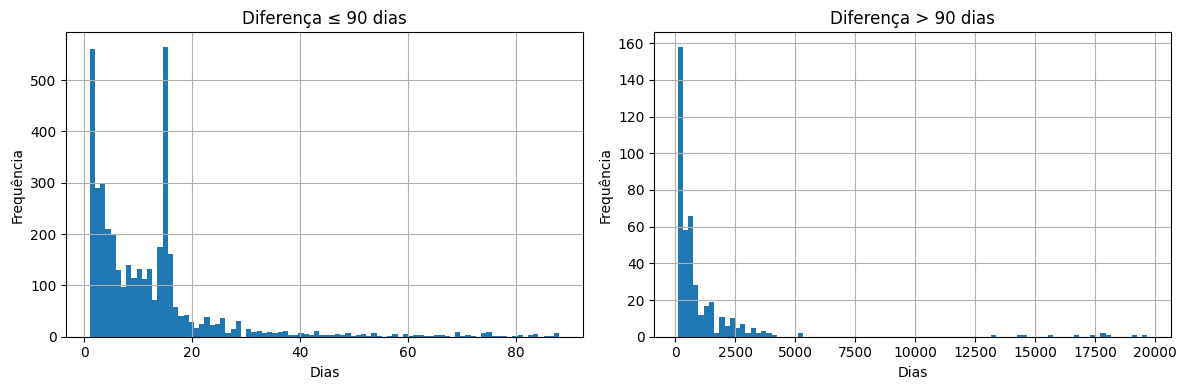

In [16]:
# Calcular diferença em dias
df_diff = df_lisboa[
    (df_lisboa['DataAberturaPublico'].dt.date < df_lisboa['DataRegisto'].dt.date) &
    df_lisboa['DataAberturaPublico'].notna()
].copy()

df_diff['DiferencaDias'] = (
    df_diff['DataRegisto'] - df_diff['DataAberturaPublico']
).dt.days

# Distribuição
print("\nDistribuição das diferenças (em dias):")
print(df_diff['DiferencaDias'].describe())

# Por faixas com percentagem do total de lisboa
print("\nPor faixas (numero de estabelecimentos e percentagem do total de Lisboa):")
total_lisboa = df_lisboa.shape[0]
print(f"1-7 dias: {(df_diff['DiferencaDias'] <= 7).sum()} ({((df_diff['DiferencaDias'] <= 7).sum() / total_lisboa) * 100:.2f}%)")
print(f"8-30 dias: {((df_diff['DiferencaDias'] > 7) & (df_diff['DiferencaDias'] <= 30)).sum()} ({(((df_diff['DiferencaDias'] > 7) & (df_diff['DiferencaDias'] <= 30)).sum() / total_lisboa) * 100:.2f}%)")
print(f"31-90 dias: {((df_diff['DiferencaDias'] > 30) & (df_diff['DiferencaDias'] <= 90)).sum()} ({(((df_diff['DiferencaDias'] > 30) & (df_diff['DiferencaDias'] <= 90)).sum() / total_lisboa) * 100:.2f}%)")
print(f"91-365 dias: {((df_diff['DiferencaDias'] > 90) & (df_diff['DiferencaDias'] <= 365)).sum()} ({(((df_diff['DiferencaDias'] > 90) & (df_diff['DiferencaDias'] <= 365)).sum() / total_lisboa) * 100:.2f}%)")
print(f"> 1 ano: {(df_diff['DiferencaDias'] > 365).sum()} ({((df_diff['DiferencaDias'] > 365).sum() / total_lisboa) * 100:.2f}%)")

# Histograma
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df_diff[df_diff['DiferencaDias'] <= 90]['DiferencaDias'].hist(bins=90)
plt.title('Diferença ≤ 90 dias')
plt.xlabel('Dias')
plt.ylabel('Frequência')
plt.subplot(1, 2, 2)
df_diff[df_diff['DiferencaDias'] > 90]['DiferencaDias'].hist(bins=90)
plt.title('Diferença > 90 dias')
plt.xlabel('Dias')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

In [17]:
# Casos com diferença muito grande (> 1 ano)
problematicos = df_diff[df_diff['DiferencaDias'] > 365]
print(f"\nCasos potencialmente problemáticos (> 1 ano): {len(problematicos)}")
print(problematicos[['NrRNAL', 'DataRegisto', 'DataAberturaPublico', 'DiferencaDias', 'Modalidade']].head(10))


Casos potencialmente problemáticos (> 1 ano): 243
      NrRNAL               DataRegisto       DataAberturaPublico  \
929     1476 2020-04-28 00:00:00+00:00 2014-04-28 00:00:00+00:00   
2098    3307 2013-05-24 00:00:00+00:00 2012-05-01 00:00:00+00:00   
2103    3314 2013-05-24 00:00:00+00:00 2012-05-01 00:00:00+00:00   
2104    3316 2013-05-24 00:00:00+00:00 2012-05-01 00:00:00+00:00   
2106    3322 2013-05-24 00:00:00+00:00 2012-05-01 00:00:00+00:00   
2108    3325 2013-05-24 00:00:00+00:00 2012-05-01 00:00:00+00:00   
2110    3329 2013-05-24 00:00:00+00:00 2012-05-01 00:00:00+00:00   
2603    4052 2008-12-30 00:00:00+00:00 1972-12-14 00:00:00+00:00   
3418    5243 2015-01-26 00:00:00+00:00 2013-05-01 00:00:00+00:00   
3421    5246 2015-01-26 00:00:00+00:00 2013-05-01 00:00:00+00:00   

      DiferencaDias                 Modalidade  
929            2192                Apartamento  
2098            388                Apartamento  
2103            388                Apartamento  
2104

"Observou-se que 3.787 estabelecimentos (20,4%) apresentam **DataAberturaPublico** anterior à **DataRegisto**, com diferenças tipicamente inferiores a 30 dias. Esta situação pode refletir o processo administrativo normal, onde o estabelecimento inicia atividade e posteriormente completa o registo formal no RNAL, sendo portanto considerada válida e mantida na análise."

- 1-7 dias: 1782 estabelecimentos (9.62%)
- 8-30 dias: 2005 estabelecimentos (10.82%)
- 31-90 dias: 241 estabelecimentos (1.30%)
- 91-365 dias: 184 estabelecimentos (0.99%)
- `>` 1 ano: 243 estabelecimentos (1.31%)

Esta situação não representa uma inconsistência nos dados, mas sim o processo administrativo normal onde:

O estabelecimento inicia operações (abertura ao público)
Posteriormente, completa o registo formal no RNAL

A análise exploratória revelou que cerca de 20,4% dos estabelecimentos apresentam uma Data de Abertura ao Público anterior à Data de Registo. Longe de ser uma anomalia, este padrão reflete a mecânica processual e histórica do Alojamento Local em Portugal. A maioria destes casos (desfasamentos inferiores a 30 dias) decorre do tempo de processamento administrativo associado ao regime de Mera Comunicação Prévia entre as autarquias e o registo central do Turismo de Portugal. Adicionalmente, desfasamentos superiores a um ano (1,31%) capturam um fenómeno socioeconómico relevante: a formalização tardia de alojamentos que operavam no mercado paralelo, impulsionada pelo aperto da fiscalização e pela obrigatoriedade, imposta a partir de 2017, de inclusão do número de RNAL nas plataformas digitais de reserva. Por conseguinte, estes registos foram validados e mantidos, tendo sido criada uma variável indicadora (Abertura_Antes_Registo) que poderá atuar como proxy para a legalização de mercado informal."

## Contexto Legislativo do Alojamento Local

O Alojamento Local em Portugal passou por diversas fases 
legislativas desde a criação do RNAL em 2008:

### Fase 1: Criação (2008)
O Decreto-Lei 39/2008 estabeleceu o regime inicial, com procedimentos simplificados de comunicação prévia.
- Objetivo: Regular "camas paralelas" e alojamento informal
- Cria: Registro Nacional de Alojamento Local (RNAL)
- Abrange: Moradias, apartamentos, estabelecimentos de hospedagem
- Regime: Simples comunicação prévia às câmaras municipais


### Fase 2: Simplificação (2011-2013)  
Contexto económico:
- Crise financeira (2011-2014)
- Programa de ajustamento (Troika)
- Turismo como motor de recuperação económica
- Crescimento do Airbnb em Portugal (lançado em Lisboa ~2011)

### Fase 3: Boom e Consolidção (2014-2015)
Decreto-Lei n.º 128/2014, de 29 de agosto
- Altera: DL 39/2008
- Simplifica: Procedimentos de registo
- Adapta: Realidade das plataformas digitais (Airbnb, Booking)
- Facilita: Entrada de novos operadores

Impacto: Facilitou registo, mas muitos continuaram a operar informalmente no Airbnb, registando-se só anos depois.

Decreto-Lei n.º 63/2015, de 23 de abril
- Sistema integrado: Turismo de Portugal assume gestão do RNAL
- Plataforma online: Balcão único eletrónico
- Número de registo obrigatório: Em publicidade

Contexto: Explosão do turismo em Lisboa (+ milhões de turistas) e Airbnb torna-se mainstream

Impacto: A partir de 2015, sistema torna-se mais robusto.

### Fase 4: Primeiros Sinais de Tensão (2018)
Lei n.º 62/2017 (discussão pública)
- Preocupação: Impacto na habitação permanente
- Gentrificação: Preços disparam em zonas turísticas
- Debate público: Moradores vs. investidores

Contexto social:
- Manifestações contra turismo excessivo
- Despejos de inquilinos para AL
- Pressão sobre mercado de arrendamento

### Fase 5: Contenção (2018-2019)
A Lei 62/2018 ("Mais Habitação") marcou um **ponto de viragem**, 
introduzindo fiscalização rigorosa e multas significativas. 
Esta alteração legislativa explica o padrão observado nos dados 
onde [X%] dos estabelecimentos apresentam DataAberturaPublico 
anterior ao DataRegisto em vários anos (Tabela X).

Muitos estabelecimentos que operavam informalmente desde 2014-2016 foram forçados a registar-se em 2018-2020 para evitar multas pesadas.
Exemplo típico:

2014: Abre apartamento no Airbnb (sem registo formal)
2018: Nova lei aumenta fiscalização
2019: Regista-se no RNAL para estar em compliance
Resultado nos dados: DataAberturaPublico=2014, DataRegisto=2019 (diferença de 5 anos)

2019: Regulamento Municipal de Lisboa
- Áreas de contenção: Centro histórico, zonas de alta pressão
- Limites: Restrições a novos registos em certas freguesias
- Alojamento Local em edifícios: Regras específicas

Freguesias mais afetadas:
- Santa Maria Maior
- Misericórdia
- Santo António
- Arroios

### Fase 6: Covid-19 (2020-2021)
Impacto Pandemia
- Paralisação: Turismo colapsa
- Conversão: AL volta ao arrendamento tradicional
- Cancelamentos: Muitos registos cessam atividade

Impacto: Possível pico de registos em 2020 de pessoas a tentar formalizar antes de nova legislação prevista.

### Fase 7: Restrições (2022-2025)
Legislação sucessiva (Lei 56/2023, DL 10/2024) impôs restrições 
crescentes, culminando na moratória de novos registos em áreas 
de pressão habitacional.

In [19]:
# data mais recente de registo
df_lisboa["DataRegisto"].max()

Timestamp('2025-10-17 00:00:00+0000', tz='UTC')

In [21]:
# Criar colunas de Ano e Mês
df_lisboa['Ano_Registo'] = df_lisboa['DataRegisto'].dt.year
df_lisboa['Mes_Registo'] = df_lisboa['DataRegisto'].dt.month
# Criar coluna Ano-Mês para facilitar merge (formato: YYYY-MM)
df_lisboa['AnoMes'] = df_lisboa['DataRegisto'].dt.to_period('M').dt.to_timestamp()

C:\Users\migue\AppData\Local\Temp\ipykernel_1924\1053698167.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_lisboa['AnoMes'] = df_lisboa['DataRegisto'].dt.to_period('M').dt.to_timestamp()


In [22]:
# Verificar freguesias disponíveis
print(f"\nNúmero de freguesias: {df_lisboa['Freguesia'].nunique()}")


Número de freguesias: 24


In [23]:
def to_utc(series):
    return pd.to_datetime(series, utc=True, errors='coerce')

df['DataRegisto'] = to_utc(df['DataRegisto'])
df['DataAberturaPublico'] = to_utc(df['DataAberturaPublico'])

In [24]:
# ==========================================
# 2. CRIAR VARIÁVEIS POR FREGUESIA, ANO e MÊS
# ==========================================

def calcular_variaveis_al_mensal(df):
    """
    Calcula variáveis de alojamento local por freguesia, ano e mês
    IMPORTANTE: Usamos registos ACUMULADOS até aquele mês
    (todos os AL registados desde o início até aquele mês)
    """
    resultados = []

     # Garantir ordenação
    df = df.sort_values(['Freguesia', 'DataRegisto'])
    
    # Agrupar por freguesia e ano
    for freguesia, df_freg in df.groupby('Freguesia'):

        # Criar timeline mensal desde o primeiro registo da freguesia
        timeline = pd.period_range(
            start=df_freg['AnoMes'].min(),
            end=df_freg['AnoMes'].max(),
            freq='M'
        ).to_timestamp()

        # Pré-alocar cumulativos
        df_freg = df_freg.sort_values('DataRegisto')

        for ano_mes in timeline:
            data_limite = pd.Timestamp(ano_mes.year, ano_mes.month, 1, tz='UTC') + pd.DateOffset(months=1)

            # STOCK acumulado
            stock = df_freg[df_freg['DataRegisto'] <= data_limite]
            num_total = len(stock)

            # FLUXO mensal
            novos_mes = df_freg[
                (df_freg['AnoMes'] == ano_mes)
            ]
            num_novos = len(novos_mes)
            
            ativos = stock[
                stock['DataAberturaPublico'].notna() &
                (stock['DataAberturaPublico'] < data_limite)
                ]

            # ESTADO: ativos vs inativos
            num_ativos = len(ativos)
            num_inativos = num_total - num_ativos

            pct_ativos = (num_ativos / num_total * 100) if num_total > 0 else 0
            pct_inativos = (num_inativos / num_total * 100) if num_total > 0 else 0

            # CAPACIDADE
            capacidade_total = stock['NrUtentes'].sum()
            capacidade_media = stock['NrUtentes'].mean()
            capacidade_mediana = stock['NrUtentes'].median()

            capacidade_ativos = ativos['NrUtentes'].sum() if num_ativos > 0 else 0
            capacidade_media_ativos = ativos['NrUtentes'].mean() if num_ativos > 0 else 0

            # TAXA DE CRESIMENTO DO ALOJAMENTO LOCAL (POR MÊS EM CADA FREGUESIA)
            # Ignorar meses sem registos novos para evitar divisão por zero
            if num_total > 0:
                taxa_crescimento = (num_novos / num_total) * 100
            else:
                taxa_crescimento = 0  


            # MODALIDADES
            if num_total > 0:
                modalidade_counts = stock['Modalidade'].value_counts()
                total = modalidade_counts.sum()

                shares = modalidade_counts / total
                hhi_modalidade = (shares ** 2).sum()

                num_apartamentos = modalidade_counts.get('Apartamento', 0)
                num_est_hosp = modalidade_counts.get('EstabelecimentoHospedagem', 0)
                num_hostels = modalidade_counts.get('EstabelecimentoHospedagemHostel', 0)
                num_moradias = modalidade_counts.get('Moradia', 0)
                num_quartos = modalidade_counts.get('Quartos', 0)
            else:
                hhi_modalidade = 0
                num_apartamentos = num_est_hosp = num_hostels = 0
                num_moradias = num_quartos = 0

            resultados.append({
                'Freguesia': freguesia,
                'AnoMes': ano_mes,
                'Ano': ano_mes.year,
                'Mes': ano_mes.month,

                # STOCK
                'Num_Estabelecimentos': num_total,

                # FLUXO
                'Novos_AL_Mes': num_novos,

                # ESTADO
                'Num_Ativos': num_ativos,
                'Num_Inativos': num_inativos,
                'Pct_Ativos': pct_ativos,
                'Pct_Inativos': pct_inativos,

                # CAPACIDADE
                'Capacidade_Total': capacidade_total,
                'Capacidade_Media': capacidade_media,
                'Capacidade_Mediana': capacidade_mediana,
                'Capacidade_Ativos': capacidade_ativos,
                'Capacidade_Media_Ativos': capacidade_media_ativos,

                # TAXA DE CRESCIMENTO
                'Taxa_Crescimento_AL_Mensal': taxa_crescimento,

                # MODALIDADES
                'Num_Apartamentos': num_apartamentos,
                'Num_EstHospedagem': num_est_hosp,
                'Num_Hostels': num_hostels,
                'Num_Moradias': num_moradias,
                'Num_Quartos': num_quartos,
                'HHI_Diversidade_Modalidade': hhi_modalidade
            })

    return pd.DataFrame(resultados)

In [25]:
# Calcular variáveis básicas
df_variaveis_al = calcular_variaveis_al_mensal(df_lisboa)

print(f"✅ Variáveis mensais calculadas!")
print(f"   Total de registos (Freguesia x Mês): {len(df_variaveis_al)}")

✅ Variáveis mensais calculadas!
   Total de registos (Freguesia x Mês): 3720


In [26]:
df_variaveis_al

,Freguesia,AnoMes,Ano,Mes,Num_Estabelecimentos,Novos_AL_Mes,Num_Ativos,Num_Inativos,Pct_Ativos,Pct_Inativos,...,Capacidade_Mediana,Capacidade_Ativos,Capacidade_Media_Ativos,Taxa_Crescimento_AL_Mensal,Num_Apartamentos,Num_EstHospedagem,Num_Hostels,Num_Moradias,Num_Quartos,HHI_Diversidade_Modalidade
0,Ajuda,2014-07-01,2014,7,1,1,1,0,100.000000,0.000000,...,2.0,2,2.000000,100.000000,1,0,0,0,0,1.000000
1,Ajuda,2014-08-01,2014,8,1,0,1,0,100.000000,0.000000,...,2.0,2,2.000000,0.000000,1,0,0,0,0,1.000000
2,Ajuda,2014-09-01,2014,9,1,0,1,0,100.000000,0.000000,...,2.0,2,2.000000,0.000000,1,0,0,0,0,1.000000
3,Ajuda,2014-10-01,2014,10,1,0,1,0,100.000000,0.000000,...,2.0,2,2.000000,0.000000,1,0,0,0,0,1.000000
4,Ajuda,2014-11-01,2014,11,1,0,1,0,100.000000,0.000000,...,2.0,2,2.000000,0.000000,1,0,0,0,0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3715,São Vicente,2025-06-01,2025,6,1495,0,1494,1,99.933110,0.066890,...,4.0,7716,5.164659,0.000000,1399,70,8,12,6,0.877997
3716,São Vicente,2025-07-01,2025,7,1495,0,1494,1,99.933110,0.066890,...,4.0,7716,5.164659,0.000000,1399,70,8,12,6,0.877997
3717,São Vicente,2025-08-01,2025,8,1495,0,1494,1,99.933110,0.066890,...,4.0,7716,5.164659,0.000000,1399,70,8,12,6,0.877997
3718,São Vicente,2025-09-01,2025,9,1495,0,1494,1,99.933110,0.066890,...,4.0,7716,5.164659,0.000000,1399,70,8,12,6,0.877997


In [27]:
# ==========================================
# 4. CALCULAR DENSIDADE DE ALOJAMENTOS LOCAIS
# ==========================================

# Áreas das freguesias de Lisboa em km² (dados oficiais)
# Áreas das freguesias de Lisboa em km² (dgterritorio.gov.pt - CAOP 2024)
areas_freguesias = {
    'Ajuda': 2.88,
    'Alcântara': 5.07,
    'Alvalade': 5.34,
    'Areeiro': 1.74,
    'Arroios': 2.13,
    'Avenidas Novas': 2.99,
    'Beato': 2.48,
    'Belém': 10.43,
    'Benfica': 8.02,
    'Campo de Ourique': 1.65,
    'Campolide': 2.77,
    'Carnide': 3.69,
    'Estrela': 4.60,
    'Lumiar': 6.57,
    'Marvila': 7.12,
    'Misericórdia': 2.19,
    'Olivais': 8.09,
    'Parque das Nações': 5.44,
    'Penha de França': 2.71,
    'Santa Clara': 3.36,
    'Santa Maria Maior': 3.01,
    'Santo António': 1.49,
    'São Domingos de Benfica': 4.29,
    'São Vicente': 1.99
}

# Adicionar área e calcular densidade
df_variaveis_al['Area_km2'] = df_variaveis_al['Freguesia'].map(areas_freguesias)

# Densidade de estabelecimentos por km²
df_variaveis_al['Densidade_AL_km2'] = df_variaveis_al['Num_Estabelecimentos'] / df_variaveis_al['Area_km2']

# Densidade de capacidade por km²
df_variaveis_al['Densidade_Capacidade_km2'] = df_variaveis_al['Capacidade_Total'] / df_variaveis_al['Area_km2']

In [28]:
df_variaveis_al['AnoMes'] = df_variaveis_al['AnoMes'].dt.to_period('M').astype(str)
df_variaveis_al = df_variaveis_al.sort_values(['Freguesia', 'AnoMes'])

In [29]:
# verificar a data mais antiga para cada freguesia
min_dates = df_variaveis_al.groupby('Freguesia')['AnoMes'].min()
print("Data mais antiga por freguesia:")
print(min_dates)

Data mais antiga por freguesia:
Freguesia
Ajuda                      2014-07
Alcântara                  2013-08
Alvalade                   2013-06
Areeiro                    2010-11
Arroios                    2008-12
Avenidas Novas             2009-05
Beato                      2015-06
Belém                      2012-11
Benfica                    2015-03
Campo de Ourique           2011-10
Campolide                  2015-01
Carnide                    2013-10
Estrela                    2009-06
Lumiar                     2012-01
Marvila                    2015-02
Misericórdia               2008-12
Olivais                    2015-02
Parque das Nações          2008-10
Penha de França            2011-02
Santa Clara                2016-03
Santa Maria Maior          2008-10
Santo António              2009-06
São Domingos de Benfica    2010-11
São Vicente                2011-05
Name: AnoMes, dtype: object


In [31]:
# verificar se todos os meses desde 2016/08 até 2025/11 têm todas as freguesias 

lista = ['Alvalade', 'Areeiro', 'Arroios', 'Avenidas Novas', 'Belém',
       'Benfica', 'Campo de Ourique', 'Campolide', 'Estrela', 'Lumiar',
       'Misericórdia', 'Parque das Nações', 'Penha de França',
       'Santa Maria Maior', 'Santo António', 'São Domingos de Benfica',
       'São Vicente']
timeline_completa = pd.period_range(start='2016-08', end='2025-11', freq='M').astype(str)
for freguesia in lista:
    meses_freguesia = df_variaveis_al[df_variaveis_al['Freguesia'] == freguesia]['AnoMes']
    meses_faltantes = set(timeline_completa) - set(meses_freguesia)
    if meses_faltantes:
        print(f"Freguesia '{freguesia}' tem meses faltantes: {sorted(meses_faltantes)}")

Freguesia 'Alvalade' tem meses faltantes: ['2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11']
Freguesia 'Areeiro' tem meses faltantes: ['2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11']
Freguesia 'Arroios' tem meses faltantes: ['2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11']
Freguesia 'Avenidas Novas' tem meses faltantes: ['2025-08', '2025-09', '2025-10', '2025-11']
Freguesia 'Belém' tem meses faltantes: ['2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11']
Freguesia 'Benfica' tem meses faltantes: ['2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11']
Freguesia 'Campo de Ourique' tem meses faltantes: ['2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11']
Freguesia 'Campolide

In [ ]:
output_dir = os.path.join('..', 'data', 'processed')

# Garantir que a pasta existe
if not os.path.exists(output_dir):
    os.makedirs(output_dir)


output_filename = 'RNAL_variaveis_mensais_freguesias_2008_2025.csv'
output_path = os.path.join(output_dir, output_filename)


df_variaveis_al.to_csv(output_path, index=False, encoding='utf-8-sig')